In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set
import json

with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 30%
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [
                        6894, # GM pet
                        6895, # GM pet
                        3080, # GM pet
                        9031, # GM pet
                        6980, # Vulbis
                        31886, # Venerable petmount
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        22206, # Alianza de corrupcion
                        22205, # Anillo de corrupcion
                              ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 6,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        # 29: {
                        #     "target": 70,  # Crit
                        #     "strength": 0.75,  # Penalty for not meeting the target
                        # }, 
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        }, 
                        28 : {
                            "target": 4, # Summons
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        }
                    },
                    "upper": {} 
                },
                "elements" : [
                    # 36, # Agility,
                    # 22, # Chance
                    # 13, # Intelligence
                    45  # Strength
                ],
                "level_offset": 10,  # Level offset for items
                "objective": "elements"  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    28:1, # Exo Summons
                    # 8:1
                    },  # Exo MP
                "distributed_points": {
                    45: 995,  # Strength
                }
            },
        }

In [3]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')
# Exclude items from the Gargandias set
config["optimizer"]["exclusions"]["items"] += Items[Items["set"].str.contains("Set de Gargandias",na=False,case=False)].index.tolist()

In [4]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2743
Total item sets: 147
Total pools:
   16 with sizes [68, 116, 1, 1, 62, 81, 39, 88, 69, 411, 326, 326, 326, 326, 326, 326]
Total combinations: 10^30.67


In [ ]:
opt.optimize()

In [ ]:
print("Best solution fitness:", opt.solution.get_fitness())
print("Best solution weapon damage:", opt.solution.get_final_weapon_damage())
print("Best solution elemental damage:", opt.solution.get_final_elemental_damage())
print("Is the solution viable?", opt.solution.viable)
print("Was the solution penalized?", opt.solution.penalized)

Best solution fitness: 441.20000000000005
Best solution weapon damage: 663.08
Best solution elemental damage: 441.20000000000005
Is the solution viable? True
Was the solution penalized? False


In [ ]:
opt.solution.totals_summary(effect_descriptions).sort_values("description",ascending=False)

,description,value
9,vitalidad,4050.0
22,suerte,300.0
10,sabiduría,390.0
25,prospección,20.0
32,potencia (daños generales),110.0
26,placaje,7.0
28,invocaciones,4.0
13,inteligencia,240.0
59,huida,-8.0
45,fuerza,1136.0


In [ ]:
set_summary = opt.solution.set_summary()
set_summary

,type_id,type,description,level,set
7043,13,Dofus,Dofus de los hielos,180,None
8693,12,Mascota,Feanor,20,None
13116,5,Bota,Botas de Brus,197,Set de Brus Bulguro
13344,13,Dofus,Dolmanax,100,None
13774,13,Trofeo,Torturador terráqueo mayor,150,None
15493,2,Daga,Dagas de Sramvil,200,None
15695,10,Sombrero,Maskrobio,200,Set de los krobios
16254,13,Trofeo,Asolador de tierra mayor,150,None
16333,13,Trofeo,Espabilador,100,None
16335,13,Trofeo,Nómada,100,None


Text(0, 0.5, 'Best Fitness')

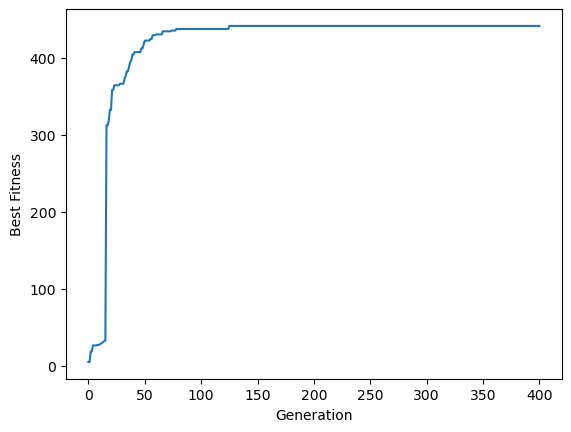

In [ ]:
import matplotlib.pyplot as plt
plt.plot(opt.ga_instance.best_solutions_fitness)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')

In [ ]:
assert False

AssertionError: 

In [ ]:
for i in opt.solution.items:
    print(i["name"]["es"], get_item_contribution(i).get(28,0))

Collar de tritáceo 0
Martillo Martirio 0
Anillo de Corrupción 0
Alianza de Corrupción 1
Cinturón de vueloceronte 0
Botas Jotdog-o 2
Rectitud de Fallanster 0
Diadema de Wulán 0
Capa Pología 0
Feanor 0
Asolador de tierra mayor 0
Espabilador 0
Rabioso mayor 0
Dofus de los hielos 0
Dofus Ocre 0
Hércules mayor 0


In [ ]:
Items[Items["name"].str.contains("anillo de corrupc",case=False)]

,name,set,level
22205,Anillo de Corrupción,Set de Corrupción,200


In [ ]:
# Current
chr = Chromosome([
                    8993, # Espada
                    13641, 13643, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    19985, # Vuelo
                    18670, # Escudo
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

1890.67

In [ ]:
Items[Items["name"].str.contains("kuko")]

,name,set,level
13989,Pluma de kukoloide,None,200
14091,Amuleto de kukoloide,Set de kukoloide,200
14092,Anillo de kukoloide,Set de kukoloide,200
14093,Botas de kukoloide,Set de kukoloide,200
13988,Ojo de kukoloide,None,200
18718,Escudo de kukoloide,Set de kukoloide,200


In [ ]:
# Project
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

2049.74

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)